# ML-QEM: Training the Error Mitigation Model (θ-Generalization)

**Step 2 of 3**: Train a Random Forest to correct noisy Pauli expectation values.

Reproduces Section C of:
> Liao et al. *Machine Learning for Practical Quantum Error Mitigation*,
> Nature Machine Intelligence 6, 594–604 (2024). arXiv:2309.17368

## Experiment design

The VQE optimizer traverses many different parameter vectors θ during minimization.
The ML model must correct noisy energy estimates at θ values it has never seen.

**Train**: first 1800 θ values → all 4 non-trivial observables (ZZ, XX, IZ, ZI)  
**Test**: held-out 200 θ values → same observables  
**Goal**: show RF corrects noisy expectation values at unseen θ, improving on unmitigated

This is the experiment that directly supports Step 3 (the VQE optimization loop),
where the model corrects energy estimates at every optimizer iteration.

In [2]:
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from qiskit.quantum_info import Pauli
from qiskit_ibm_runtime.fake_provider import FakeLimaV2
import joblib

print('All imports OK')

All imports OK


## 1. Load Dataset

In [3]:
ideal_data    = np.load('ideal_data.npy')     # shape (2000, 5)
noisy_data    = np.load('noisy_data.npy')     # shape (2000, 5)
theta_samples = np.load('theta_samples.npy')  # shape (2000, 8)

with open('dataset_meta.json') as f:
    meta = json.load(f)

PAULI_LABELS = meta['pauli_labels']   # ['II', 'IZ', 'ZI', 'ZZ', 'XX']
PAULI_COEFFS = meta['hamiltonian_coeffs']

print(f'Dataset: {ideal_data.shape[0]} samples, {ideal_data.shape[1]} Pauli terms')
print(f'Pauli labels:       {PAULI_LABELS}')
print(f'Pauli coefficients: {[round(c,7) for c in PAULI_COEFFS]}')

# ── Train/test split on θ ─────────────────────────────────────────────────────
N_TRAIN = 1800
N_TEST  = 200   # = 2000 - 1800

ideal_train = ideal_data[:N_TRAIN]
noisy_train = noisy_data[:N_TRAIN]
ideal_test  = ideal_data[N_TRAIN:]
noisy_test  = noisy_data[N_TRAIN:]

print(f'\nTrain: {N_TRAIN} theta values')
print(f'Test:  {N_TEST} theta values (held out, never seen during training)')

Dataset: 2000 samples, 5 Pauli terms
Pauli labels:       ['II', 'IZ', 'ZI', 'ZZ', 'XX']
Pauli coefficients: [-1.0523732, 0.3979374, -0.3979374, -0.0112801, 0.1809312]

Train: 1800 theta values
Test:  200 theta values (held out, never seen during training)


## 2. Extract Per-Qubit Device Noise Parameters

Following Liao et al. (Methods Section IV.A), per-qubit device noise parameters
(T1, T2, readout error) are included as features alongside the circuit descriptors.

In [4]:
backend = FakeLimaV2()
props   = backend.properties()

N_QUBITS = 2
qubit_props = {}
for q in range(N_QUBITS):
    t1  = props.qubit_property(q, 'T1')[0] * 1e6
    t2  = props.qubit_property(q, 'T2')[0] * 1e6
    err = props.qubit_property(q, 'readout_error')[0]
    qubit_props[q] = {'T1': t1, 'T2': t2, 'readout_error': err}
    print(f'Qubit {q}: T1={t1:.2f}µs  T2={t2:.2f}µs  readout_err={err:.4f}')

Qubit 0: T1=59.70µs  T2=93.56µs  readout_err=0.0261
Qubit 1: T1=83.06µs  T2=115.53µs  readout_err=0.0200


## 3. Build Features

Feature vector per (circuit, observable) pair — 13 features total:

| Feature | Description |
|---------|-------------|
| `noisy_exp_val` | Noisy expectation value — implicitly encodes θ |
| `x_q0, x_q1, z_q0, z_q1` | Symplectic Pauli encoding (structural observable info) |
| `n_2q, n_1q` | Gate counts (circuit depth proxies) |
| `T1_q0, T2_q0, ro_q0` | Qubit 0 noise params, masked if observable doesn't act on it |
| `T1_q1, T2_q1, ro_q1` | Qubit 1 noise params, masked if observable doesn't act on it |

**Note**: θ is NOT a feature. The noisy expectation value already encodes the
quantum state |ψ(θ)⟩ implicitly — the model generalizes to new θ values
automatically because it learns to correct any noisy value in the observed range.

In [5]:
def pauli_to_symplectic(pauli_str):
    p = Pauli(pauli_str)
    return np.concatenate([p.x.astype(int), p.z.astype(int)])

SYMPLECTIC = {label: pauli_to_symplectic(label) for label in PAULI_LABELS}

# Gate counts for TwoLocal reps=3, 2 qubits
N_2Q = 3
N_1Q = 8

def qubit_noise_features(symp):
    feats = []
    for q in range(N_QUBITS):
        active = float(symp[q] == 1 or symp[q + N_QUBITS] == 1)
        feats.extend([
            qubit_props[q]['T1']            * active,
            qubit_props[q]['T2']            * active,
            qubit_props[q]['readout_error'] * active,
        ])
    return feats

def build_features(noisy_subset, ideal_subset, observable_indices):
    """
    Build feature matrix for the RF.
    Each row = one (circuit at θ_i, observable_j) pair.
    """
    N = len(noisy_subset)
    rows_X, rows_y = [], []
    for obs_idx in observable_indices:
        label       = PAULI_LABELS[obs_idx]
        symp        = SYMPLECTIC[label]
        noise_feats = qubit_noise_features(symp)
        for i in range(N):
            rows_X.append([
                noisy_subset[i, obs_idx],
                *symp,
                N_2Q, N_1Q,
                *noise_feats,
            ])
            rows_y.append(ideal_subset[i, obs_idx])
    return np.array(rows_X), np.array(rows_y)

# Use all non-trivial observables: IZ, ZI, ZZ, XX  (skip II which is always 1.0)
ALL_OBS = [1, 2, 3, 4]   # IZ, ZI, ZZ, XX

X_train, y_train = build_features(noisy_train, ideal_train, ALL_OBS)
X_test,  y_test  = build_features(noisy_test,  ideal_test,  ALL_OBS)

print(f'Training set: {X_train.shape}')
print(f'  = {N_TRAIN} theta values x {len(ALL_OBS)} observables = {N_TRAIN*len(ALL_OBS)} rows')
print(f'Test set:     {X_test.shape}')
print(f'  = {N_TEST} held-out theta values x {len(ALL_OBS)} observables = {N_TEST*len(ALL_OBS)} rows')
print(f'\nFeatures: [noisy_val | x_q0 x_q1 z_q0 z_q1 | n_2q n_1q | T1_q0 T2_q0 ro_q0 T1_q1 T2_q1 ro_q1]')

Training set: (7200, 13)
  = 1800 theta values x 4 observables = 7200 rows
Test set:     (800, 13)
  = 200 held-out theta values x 4 observables = 800 rows

Features: [noisy_val | x_q0 x_q1 z_q0 z_q1 | n_2q n_1q | T1_q0 T2_q0 ro_q0 T1_q1 T2_q1 ro_q1]


## 4. Train Random Forest

In [6]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

train_pred   = rf.predict(X_train)
test_pred    = rf.predict(X_test)
baseline     = X_test[:, 0]   # unmitigated = just use the noisy value

train_mae    = mean_absolute_error(y_train, train_pred)
test_mae     = mean_absolute_error(y_test,  test_pred)
baseline_mae = mean_absolute_error(y_test,  baseline)

print(f'Training MAE  (seen θ):        {train_mae:.4f}')
print(f'Test MAE      (unseen θ):      {test_mae:.4f}')
print(f'Baseline MAE  (unmitigated):   {baseline_mae:.4f}')
print(f'\nImprovement over unmitigated: {baseline_mae / test_mae:.1f}x')

Training MAE  (seen θ):        0.0034
Test MAE      (unseen θ):      0.0084
Baseline MAE  (unmitigated):   0.0349

Improvement over unmitigated: 4.2x


## 5. Per-Observable Breakdown

How well does the RF correct each Pauli term at unseen θ values?

In [7]:
print(f'{"Observable":<10} {"Unmitigated MAE":>18} {"RF-Mitigated MAE":>18} {"Improvement":>12}')
print('-' * 60)

for obs_idx, label in enumerate(PAULI_LABELS):
    if obs_idx == 0:
        continue

    ideal_vals  = ideal_test[:, obs_idx]
    noisy_vals  = noisy_test[:, obs_idx]
    symp        = SYMPLECTIC[label]
    noise_feats = qubit_noise_features(symp)
    N           = len(noisy_test)

    features = np.column_stack([
        noisy_vals,
        np.tile(symp,        (N, 1)),
        np.full((N, 1), N_2Q),
        np.full((N, 1), N_1Q),
        np.tile(noise_feats, (N, 1)),
    ])
    corrected       = rf.predict(features)
    unmitigated_mae = mean_absolute_error(ideal_vals, noisy_vals)
    mitigated_mae   = mean_absolute_error(ideal_vals, corrected)
    improvement     = unmitigated_mae / mitigated_mae if mitigated_mae > 0 else float('inf')

    print(f'{label:<10} {unmitigated_mae:>18.4f} {mitigated_mae:>18.4f} {improvement:>11.1f}x')

Observable    Unmitigated MAE   RF-Mitigated MAE  Improvement
------------------------------------------------------------
IZ                     0.0261             0.0084         3.1x
ZI                     0.0220             0.0085         2.6x
ZZ                     0.0469             0.0077         6.1x
XX                     0.0446             0.0089         5.0x


## 6. Plots

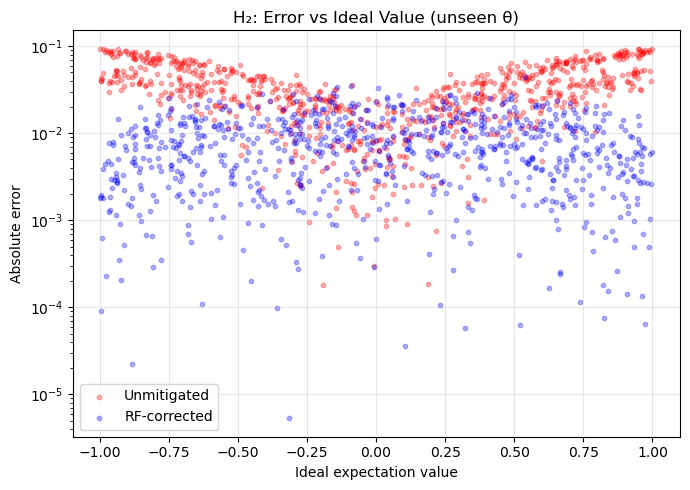

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))

errors_unm = np.abs(y_test - baseline)
errors_rf  = np.abs(y_test - test_pred)

ax.scatter(y_test, errors_unm, alpha=0.3, s=10, color='red', label='Unmitigated')
ax.scatter(y_test, errors_rf, alpha=0.3, s=10, color='blue', label='RF-corrected')
ax.set_yscale('log')
ax.set_xlabel('Ideal expectation value')
ax.set_ylabel('Absolute error')
ax.set_title('H₂: Error vs Ideal Value (unseen θ)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('h2_rf_error.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Model and Results

In [13]:
joblib.dump(rf, 'rf_mlqem.joblib')
print('Saved: rf_mlqem.joblib')

Saved: rf_mlqem.joblib
